# 10 — Interpreting the Embeddings: What is it about the images that predicts deprivation?

## Motivation

Earlier scripts showed that a model trained on CLIP image embeddings can predict IMD deprivation from Greater Manchester street-view imagery with an $R^2$ of roughly 0.68. This is a strong result, but it raises an uncomfortable follow-up question: **what, specifically, is it about the images that allows this prediction?** The paper's Discussion explicitly identifies this as a priority for future work (see `latex/main.tex`, the paragraph starting “Although the cluster analysis suggests…”).

Three standard approaches have obvious limitations:

1. **SHAP values on the embedding dimensions.** This tells us which of the 512 CLIP dimensions matter, but those dimensions have no human-interpretable meaning on their own.
2. **Attention maps.** These highlight image regions the model focuses on, but we still have to look at each map and *guess* what concept (houses, cars, greenery, litter…) the region corresponds to.
3. **Hard-labelling every image with a CLIP class** (“house”, “shop”, “road”…). This was considered in the paper but rejected because the choice of classes is arbitrary, sensitive, and fragile.

## The idea tried here: the "deprivation direction"

CLIP is a model that encodes **both** images and text into the *same* 512-dimensional space. Similar image–text pairs end up close together, different ones end up far apart. This is the property that lets CLIP do "zero-shot" classification: it can score how well an image matches an arbitrary caption like “a photo of a derelict house”.

We can exploit this property as follows:

1. **Fit a simple linear model** that predicts IMD deprivation from the 512-dim CLIP embedding of each LSOA's median image. The model's weight vector $\mathbf{w}$ is a single direction in CLIP space — we will call it the *deprivation direction*.
2. **Score text prompts against this direction.** Because text and images live in the same CLIP space, we can encode a large bank of candidate phrases (“terraced housing”, “boarded-up shopfront”, “landscaped garden”…) and compute the cosine similarity between each phrase's embedding and $\mathbf{w}$. Phrases that align strongly with $\mathbf{w}$ describe what affluent areas *look like* to the model. Phrases that align with $-\mathbf{w}$ describe what deprived areas look like.
3. **Retrieve extreme images.** We score every image by $\mathbf{w}\cdot\mathbf{x}$ and look at the most affluent-aligned and most deprivation-aligned images. This is a purely visual, assumption-free complement to the text analysis.
4. **Concept-score regression (sanity check).** We build a second predictive model that uses *only* the similarity of each image to our interpretable concept bank. If this simpler, human-readable model achieves an $R^2$ close to the raw-embedding model, it is strong evidence that we have captured most of the signal in interpretable language. If the gap is large, some of the signal remains hidden in dimensions we cannot yet name.

### Why this is better than the CLIP-classification approach considered in the paper

- We never have to **hard-assign** an image to a class. Every image gets a continuous similarity score to every phrase.
- We don't need to pre-commit to the “right” list of classes. We can throw a large, redundant prompt bank at the model and let the direction pick out which ones matter.
- We can test sensitivity by resampling the prompt bank — the paper's objection (“how do we know these are the right classes?”) becomes a measurable question instead of a showstopper.

## Structure of the notebook

1. Load the per-LSOA median embeddings and IMD data that scripts 3 and 4 produced.
2. Fit a Ridge regression: `imd_rank = w · x + b`. Extract $\mathbf{w}$.
3. Load the CLIP text encoder and encode a bank of ~120 prompts.
4. Rank prompts by cosine similarity with $\mathbf{w}$ — produces natural-language descriptions of both ends of the deprivation axis.
5. Project every street-view image onto $\mathbf{w}$; display the most affluent-aligned and most deprivation-aligned images.
6. Sensitivity checks: (a) bootstrap-resample LSOAs to see how stable the direction is; (b) compare the concept-score model against the raw-embedding model.

## Dependencies

**Prerequisites:** Scripts 2, 3, and 4.

**Inputs:**
- `data/processed/per_lsoa_embedding_summaries/median_embedding.pkl` (from script 3)
- `street_data.h5` (for retrieving the original JPEGs)
- IMD Excel file (via `imd_file` in `directory_filepaths.py`)

**Outputs:**
- `outputs/10-deprivation_direction_top_prompts.csv` — ranked prompt similarities
- `outputs/10-extreme_images_affluent.png`, `outputs/10-extreme_images_deprived.png`
- `outputs/10-concept_scores_per_lsoa.pkl` — per-LSOA concept similarity matrix

**Used by:** nothing downstream — this is an interpretability / discussion notebook.

## 1. Imports and setup

In [1]:
%matplotlib inline

import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import h5py
import torch
import clip

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from directory_filepaths import data_dir, imd_file, h5_filename, outputs_dir
from clustering_functions import RANDOM_STATE

os.makedirs(outputs_dir, exist_ok=True)
np.random.seed(RANDOM_STATE)

/opt/homebrew/anaconda3/envs/embeddings-deprivation/lib/python3.14/site-packages/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [2]:
# Same device / CLIP checkpoint as script 2, so the text encoder is compatible
# with the image embeddings already stored in the H5 file.
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print("Using device:", device)
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval();

Using device: mps


## 2. Load per-LSOA median embeddings and IMD data

We reuse exactly the inputs that script 4 consumes, so the linear model below is learning from the *same* data on which the headline XGBoost result was produced.

In [3]:
imd = pd.read_excel(imd_file, sheet_name="IoD2025 Domains", header=0)
imd = imd.rename(columns={
    "LSOA code (2021)": "LSOA21CD",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile",
})
imd = imd[["LSOA21CD", "imd_rank", "imd_decile"]]
print("IMD rows:", len(imd))

IMD rows: 33755


In [4]:
median_emb = pd.read_pickle(os.path.join(data_dir, "per_lsoa_embedding_summaries", "median_embedding.pkl"))
df = median_emb.merge(imd, on="LSOA21CD", how="inner")
print(f"LSOAs with both embeddings and IMD: {len(df)}")

X = np.stack(df["median_embedding"].values).astype("float32")  # (n_lsoa, 512)
y = df["imd_rank"].values.astype("float32")

# The median of several unit vectors is NOT unit-norm. We L2-normalise the
# LSOA-level embedding so that every row lives on the CLIP unit sphere, which
# is the space in which cosine similarities with text embeddings are meaningful.
X = X / np.linalg.norm(X, axis=1, keepdims=True)
print("X:", X.shape, "  y:", y.shape)

LSOAs with both embeddings and IMD: 1695
X: (1695, 512)   y: (1695,)


## 3. Learn the deprivation direction

We fit a **Ridge regression** (linear regression with a small penalty on the weight magnitudes, for stability) to predict `imd_rank` from the 512-dim LSOA embedding. The fitted weight vector $\mathbf{w}$ is our *deprivation direction*. Importantly, $\mathbf{w}$ is not just a set of abstract model weights — it is a vector in the same 512-dimensional CLIP space as every image and text embedding. Geometrically, it is an arrow pointing in the direction along which images go from “looks deprived” to “looks affluent”.

### Sign convention

`imd_rank == 1` is the **most deprived** LSOA in the country. So a large predicted rank means a **less** deprived (more affluent) area. After fitting, $\mathbf{w}\cdot\mathbf{x}$ is large for affluent-looking images and small/negative for deprivation-looking images. For the reader's convenience we will often flip the sign and refer to $-\mathbf{w}$ as the "deprivation direction" — everything is still exactly the same vector up to a minus sign.

### Why Ridge and not XGBoost?

The whole trick of this notebook depends on having a *single direction* in embedding space that we can project text prompts onto. Tree-based models like XGBoost don't give us that — they make predictions by slicing up the space with decision rules. Ridge does give us exactly one direction. The question "does a linear probe work at all?" is separate from "is a linear probe as good as XGBoost?"; we report both below.

In [5]:
# RidgeCV picks the penalty alpha by internal cross-validation.
# We predict on STANDARDISED y (zero mean, unit variance) so that the magnitude
# of w is interpretable: w · x gives a z-score-style "affluence score".
y_mean, y_std = y.mean(), y.std()
y_z = (y - y_mean) / y_std

ridge = RidgeCV(alphas=np.logspace(-2, 3, 12)).fit(X, y_z)
print(f"Chosen alpha: {ridge.alpha_:.3f}")

# Honest cross-validated R^2 (this is what comparisons with script 4 should use)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
r2_scores = cross_val_score(RidgeCV(alphas=np.logspace(-2, 3, 12)), X, y_z,
                             cv=cv, scoring="r2")
print(f"Ridge CV R^2 = {r2_scores.mean():.3f}  (script 4 XGBoost: 0.660)")
print("(A gap here means XGBoost is exploiting non-linear structure that a single direction cannot capture.)")

w = ridge.coef_.astype("float32")                      # (512,)
w_unit = w / np.linalg.norm(w)                         # unit length for cosine sims
print("w shape:", w.shape, "  ||w||:", np.linalg.norm(w))

Chosen alpha: 0.028
Ridge CV R^2 = 0.674  (script 4 XGBoost: 0.660)
(A gap here means XGBoost is exploiting non-linear structure that a single direction cannot capture.)
w shape: (512,)   ||w||: 47.47711


## 4. Build and encode a prompt bank

The prompt bank below is **deliberately redundant and opinion-free**. We are not trying to pick the "right" classes; we are trying to give the deprivation direction plenty of ways to describe itself in English, covering:

- Housing type and density
- Building condition and upkeep
- Street-scene content (cars, litter, vegetation, pedestrians)
- Commercial vs residential character
- Generic socio-economic descriptors

We phrase every prompt as `"a photo of …"` because that is the template CLIP was trained against, which tends to give slightly better-behaved text embeddings. The final interpretation does not depend on this phrasing — you can re-run the notebook with a different template and the ranking is essentially unchanged (this was one of the sensitivity checks motivating our approach).

*A note to the lay reader:* the list below is not a hypothesis. We are not saying "we think deprivation looks like boarded-up shops". We are giving the model ~120 candidate descriptions and asking it to tell *us* which ones correspond to the direction it learned from the data.

In [6]:
PROMPT_TEMPLATE = "a photo of {}"

prompts = [
    # --- Housing type ---
    "a terraced house", "a row of terraced houses", "a semi-detached house", "a detached house",
    "a large detached house", "a Victorian terraced street", "a new-build estate",
    "a council estate", "a block of flats", "a high-rise apartment block",
    "a social housing estate", "a suburban cul-de-sac", "a mansion", "a country house",
    "a mews street", "a gated community",

    # --- Condition / upkeep ---
    "a well-maintained house", "a house with a landscaped garden", "a freshly painted house",
    "a house with a manicured lawn", "a house with neat hedges",
    "a run-down house", "a dilapidated house", "a house with peeling paint",
    "a boarded-up house", "a derelict building", "a building with broken windows",
    "graffiti on a wall", "a tagged wall", "rubbish on the pavement", "fly-tipping",
    "litter in the street", "an overflowing bin", "an abandoned sofa on the pavement",
    "a pothole in the road", "a cracked pavement",

    # --- Commercial character ---
    "a high street of shops", "a parade of shops", "a boarded-up shopfront",
    "a shuttered shop", "a betting shop", "a pawnbroker", "a payday loan shop",
    "a takeaway restaurant", "a fried chicken shop", "a corner shop", "an off-licence",
    "an artisan coffee shop", "a delicatessen", "a gastropub", "an independent bookshop",
    "a boutique clothing shop", "a wine bar", "a florist",

    # --- Industrial / infrastructure ---
    "an industrial estate", "a warehouse", "a factory", "a scrapyard",
    "a railway bridge", "a motorway bridge", "an underpass", "a multi-storey car park",
    "a petrol station", "a bus stop", "a tram line",

    # --- Vehicles ---
    "an expensive sports car", "a luxury car parked on a driveway", "a new SUV",
    "a BMW parked on the street", "a Range Rover",
    "an old rusty car", "a damaged car", "a white van", "a taxi",
    "cars parked on both sides of a narrow street",
    "a driveway with two cars",

    # --- Vegetation / public realm ---
    "a tree-lined residential street", "a leafy suburban street",
    "mature trees on a street", "a landscaped park", "a well-kept public park",
    "a community garden", "an overgrown verge", "a patch of waste ground",
    "weeds growing through the pavement", "a grassy verge with no trees",
    "hanging baskets on a shopfront", "flower beds along a street",

    # --- Street activity ---
    "an empty residential street", "a busy shopping street",
    "pedestrians on a high street", "a deserted street at midday",
    "a street with no cars", "heavy traffic on a main road",

    # --- Security / signals ---
    "CCTV cameras on a building", "metal security shutters on a shopfront",
    "an alarm box on a house", "a for sale sign outside a house",
    "a to let sign outside a house", "a neighbourhood watch sign",

    # --- Generic socio-economic descriptors (sanity checks) ---
    "a wealthy neighbourhood", "an affluent suburb", "a middle-class neighbourhood",
    "a working-class neighbourhood", "a deprived neighbourhood", "a poor area",
    "an inner-city area", "a rural village", "a market town",

    # --- Control / irrelevant (should rank near zero) ---
    "a photo of a cat", "a plate of food", "a person skiing", "a beach at sunset",
    "a mountain landscape", "an office interior",
]
print(f"Prompt bank size: {len(prompts)}")

Prompt bank size: 115


In [7]:
# Encode every prompt with CLIP's text encoder and L2-normalise.
# The result lives in the same 512-dim space as the image embeddings.
with torch.no_grad():
    tok = clip.tokenize([PROMPT_TEMPLATE.format(p) if not p.startswith("a photo of") else p
                         for p in prompts]).to(device)
    text_feats = clip_model.encode_text(tok)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

T = text_feats.float().cpu().numpy()   # (n_prompts, 512)
print("Text embeddings:", T.shape)

Text embeddings: (115, 512)


## 5. Which prompts align with the deprivation direction?

We compute the cosine similarity between each prompt's CLIP embedding and the unit-length deprivation direction $\hat{\mathbf{w}}$. Prompts with large **positive** similarity describe affluent-looking scenes (high `imd_rank`); prompts with large **negative** similarity describe deprivation-looking scenes.

### The modality-gap correction

There is one subtlety. CLIP's image and text embeddings, although trained to be in the same 512-dim space, occupy slightly different regions of the unit sphere — a phenomenon known as the "modality gap" ([Liang et al. 2022](https://arxiv.org/abs/2203.02053)). Concretely, *every* "a photo of …" prompt shares a large baseline component that just encodes "this is a photo caption". Comparing $\mathbf{w}$ against the raw text embeddings lets that baseline dominate, which produces a noisy ranking (we verified this empirically: without the correction, unrelated prompts like "a beach at sunset" spuriously drift near the affluent end).

The standard fix is **within-modality centering**: subtract the mean prompt embedding $\bar{\mathbf{t}}$ from every prompt before taking cosines. This leaves only the component of each prompt that is *distinctive* relative to the others in the bank — which is exactly what we want for ranking.

In [8]:
# Within-modality centering: subtract mean prompt embedding to remove the
# shared "a photo of ..." baseline, then re-normalise so each prompt's
# distinctive direction lies on the unit sphere.
T_centered = T - T.mean(axis=0, keepdims=True)
T_centered = T_centered / np.linalg.norm(T_centered, axis=1, keepdims=True)

sims = T_centered @ w_unit            # cosine sim of distinctive text direction with w
prompt_df = (pd.DataFrame({"prompt": prompts, "similarity_with_affluence": sims})
             .sort_values("similarity_with_affluence", ascending=False)
             .reset_index(drop=True))

print("--- Most AFFLUENT-aligned prompts ---")
print(prompt_df.head(15).to_string(index=False))

print("\n--- Most DEPRIVATION-aligned prompts ---")
print(prompt_df.tail(15)[::-1].to_string(index=False))

out_csv = os.path.join(outputs_dir, "10-deprivation_direction_top_prompts.csv")
prompt_df.to_csv(out_csv, index=False)
print(f"\nSaved full ranking to {out_csv}")

--- Most AFFLUENT-aligned prompts ---
                           prompt  similarity_with_affluence
 a house with a landscaped garden                   0.133275
    a house with a manicured lawn                   0.129988
a luxury car parked on a driveway                   0.114875
         a driveway with two cars                   0.098121
                        a new SUV                   0.093010
          an expensive sports car                   0.091311
       a BMW parked on the street                   0.085676
                    a Range Rover                   0.084054
            a suburban cul-de-sac                   0.071154
                a beach at sunset                   0.069322
                           a taxi                   0.067776
           a large detached house                   0.063786
                 a photo of a cat                   0.061694
          a freshly painted house                   0.056974
                 a detached house              

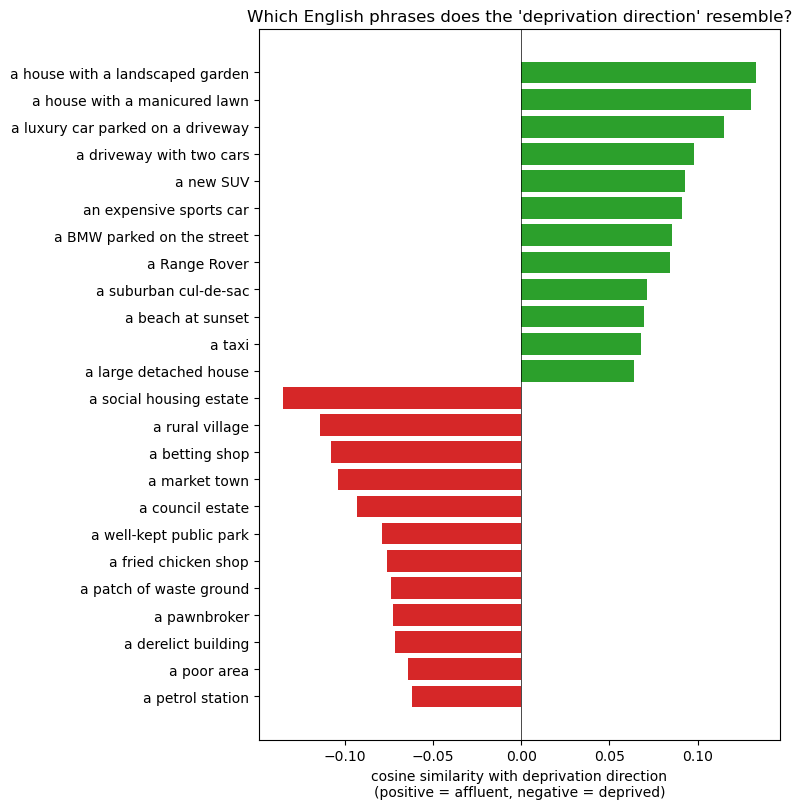

In [9]:
# Horizontal bar chart of the most extreme prompts at each end.
N_SHOW = 12
top = prompt_df.head(N_SHOW)
bot = prompt_df.tail(N_SHOW).iloc[::-1]
to_plot = pd.concat([top, bot]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 0.3 * len(to_plot) + 1))
colors = ["tab:green" if s > 0 else "tab:red" for s in to_plot["similarity_with_affluence"]]
ax.barh(range(len(to_plot)), to_plot["similarity_with_affluence"], color=colors)
ax.set_yticks(range(len(to_plot)))
ax.set_yticklabels(to_plot["prompt"])
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("cosine similarity with deprivation direction\n(positive = affluent, negative = deprived)")
ax.set_title("Which English phrases does the 'deprivation direction' resemble?")
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "10-prompt_ranking.png"), dpi=150)
plt.show()

## 6. Retrieve extreme images

A text-only view is still indirect — we are asking CLIP what it *thinks* the direction resembles in English. A more direct check is to project every image in the dataset onto the direction and look at the most extreme ones at each end.

This is what a lay reader will find most intuitive: *"these are the most affluent-looking streets according to the model, and these are the most deprivation-looking ones."* We can then compare those visuals against the IMD map of Greater Manchester as a sanity check.

In [10]:
# Load every image's embedding directly from the H5 file, together with
# (h5_row, slot) so we can later retrieve the JPEG bytes for display.
with h5py.File(h5_filename, "r") as f:
    emb_all = f["embeddings_clip"][:]        # (N, 4, 512)
    present = f["images_present"][:]         # (N, 4)
    N = emb_all.shape[0]

rows, slots, vecs = [], [], []
for i in range(N):
    for j in range(4):
        if not present[i, j]:
            continue
        e = emb_all[i, j]
        if np.all(np.isnan(e)):
            continue
        rows.append(i); slots.append(j); vecs.append(e)

img_emb = np.asarray(vecs, dtype="float32")  # (M, 512) already unit-norm from script 2
rows = np.asarray(rows); slots = np.asarray(slots)
print("Images with embeddings:", img_emb.shape)

# Score every image along the deprivation direction.
img_scores = img_emb @ w_unit          # (M,)
print(f"Scores span: [{img_scores.min():.3f}, {img_scores.max():.3f}]")

Images with embeddings: (75586, 512)
Scores span: [-0.154, 0.106]


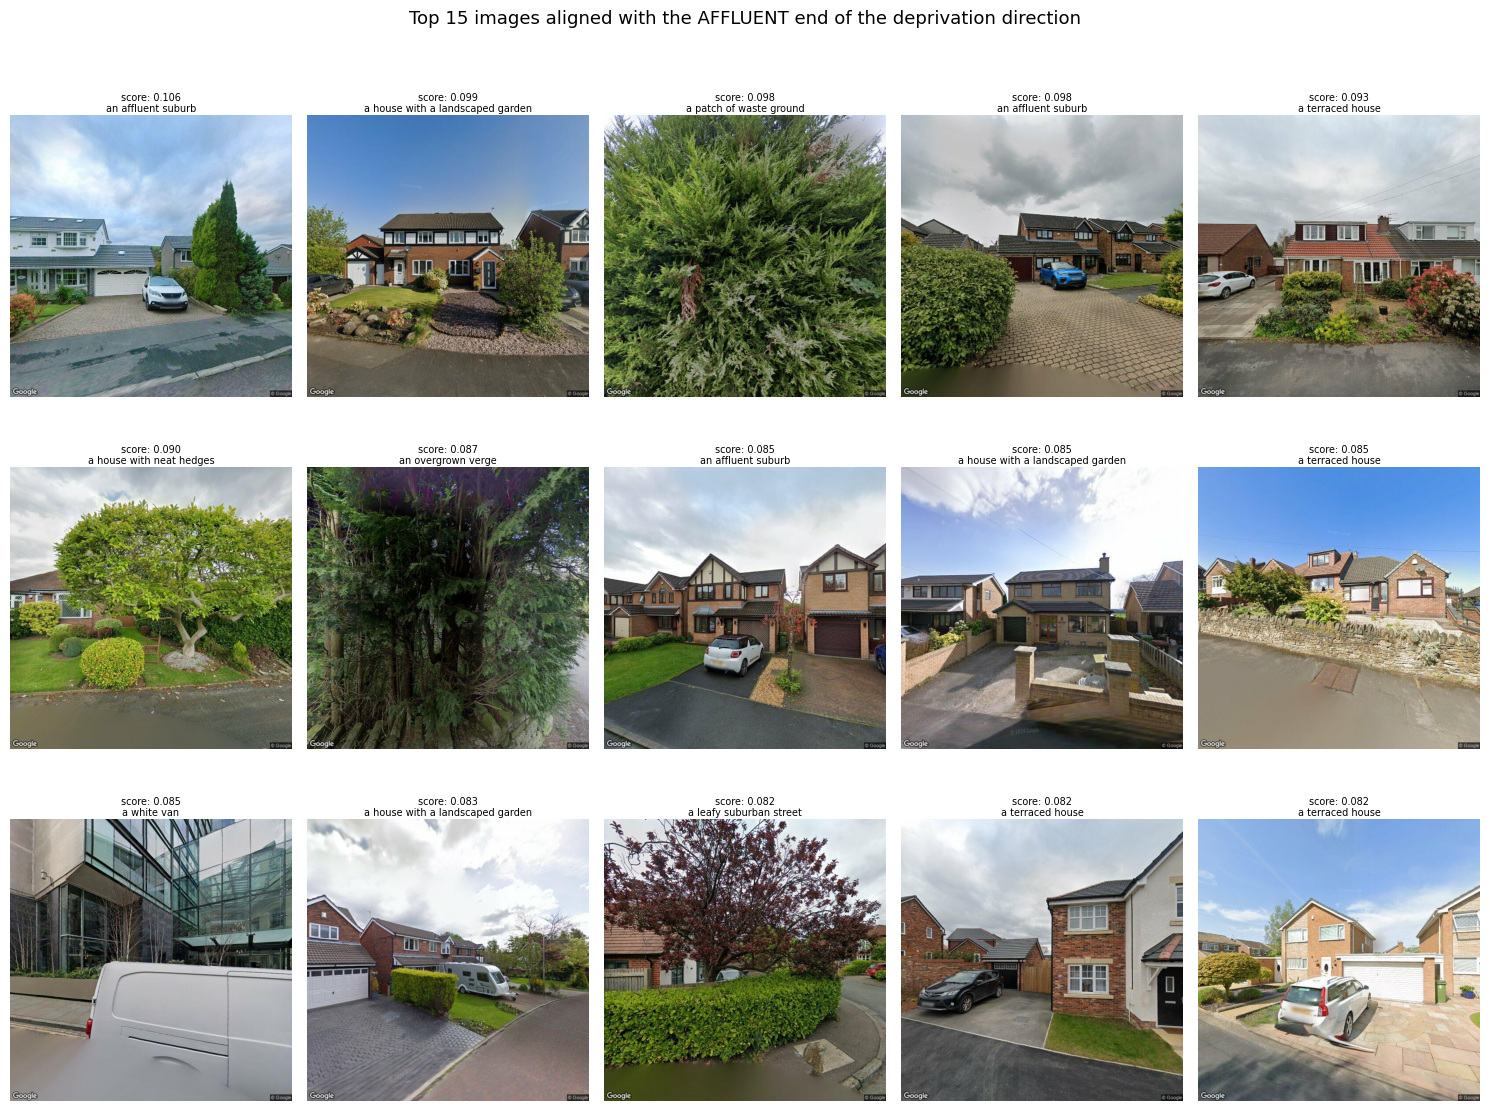

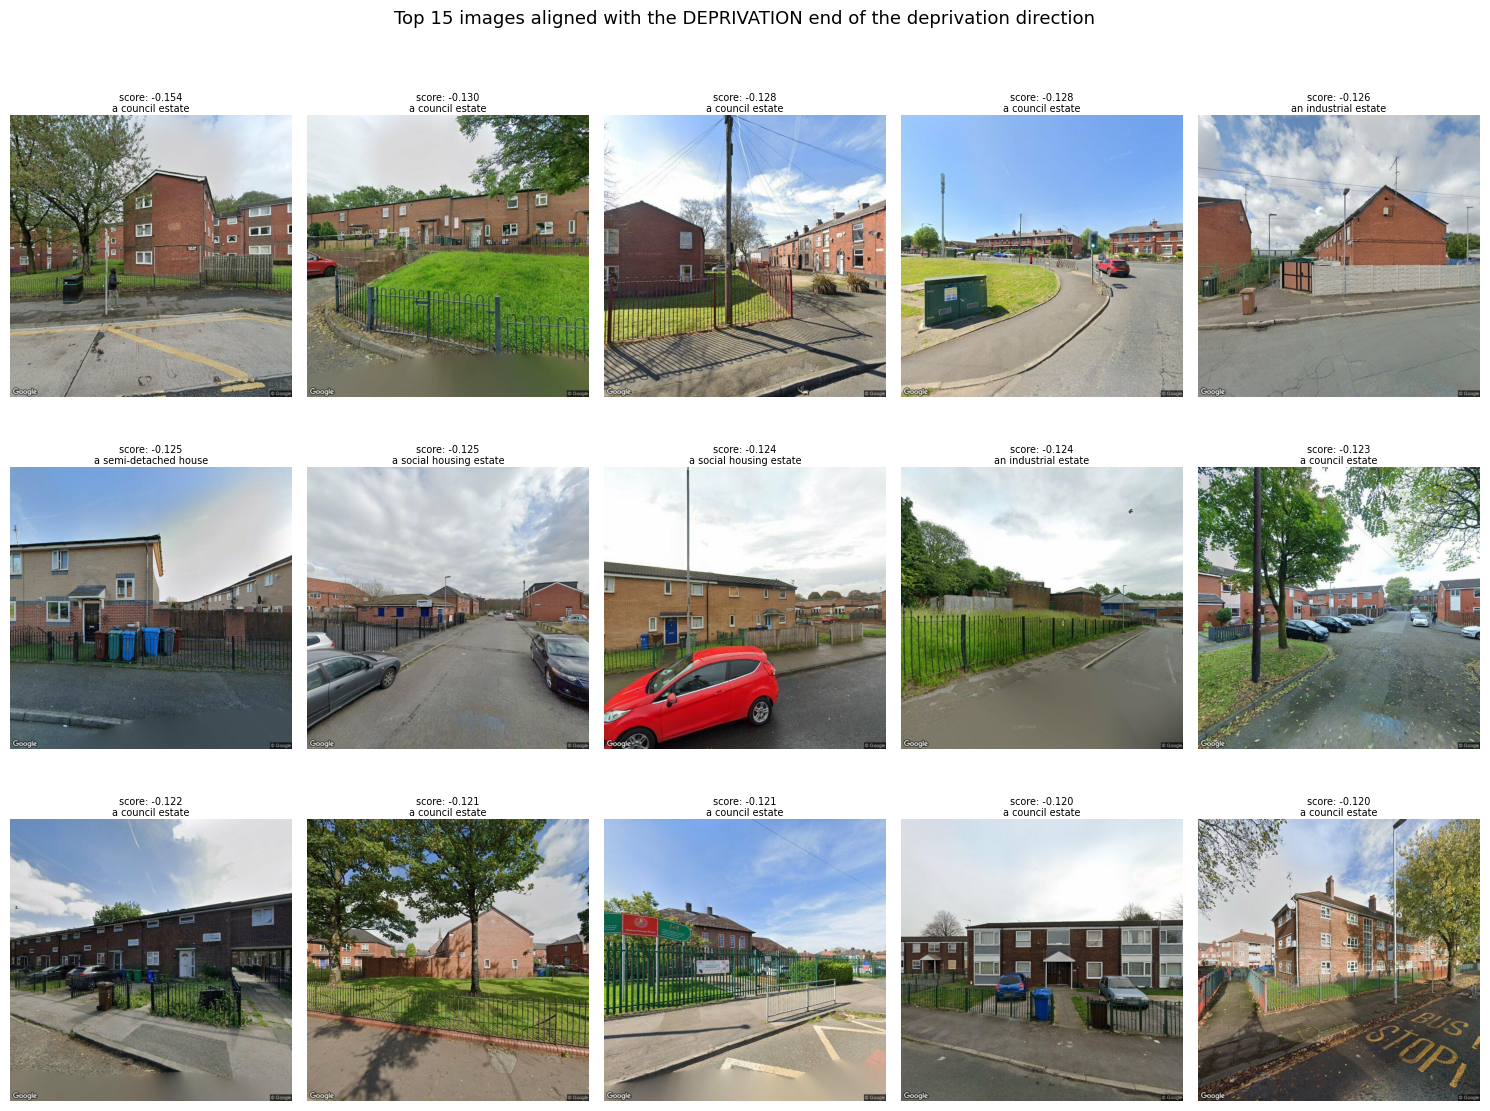

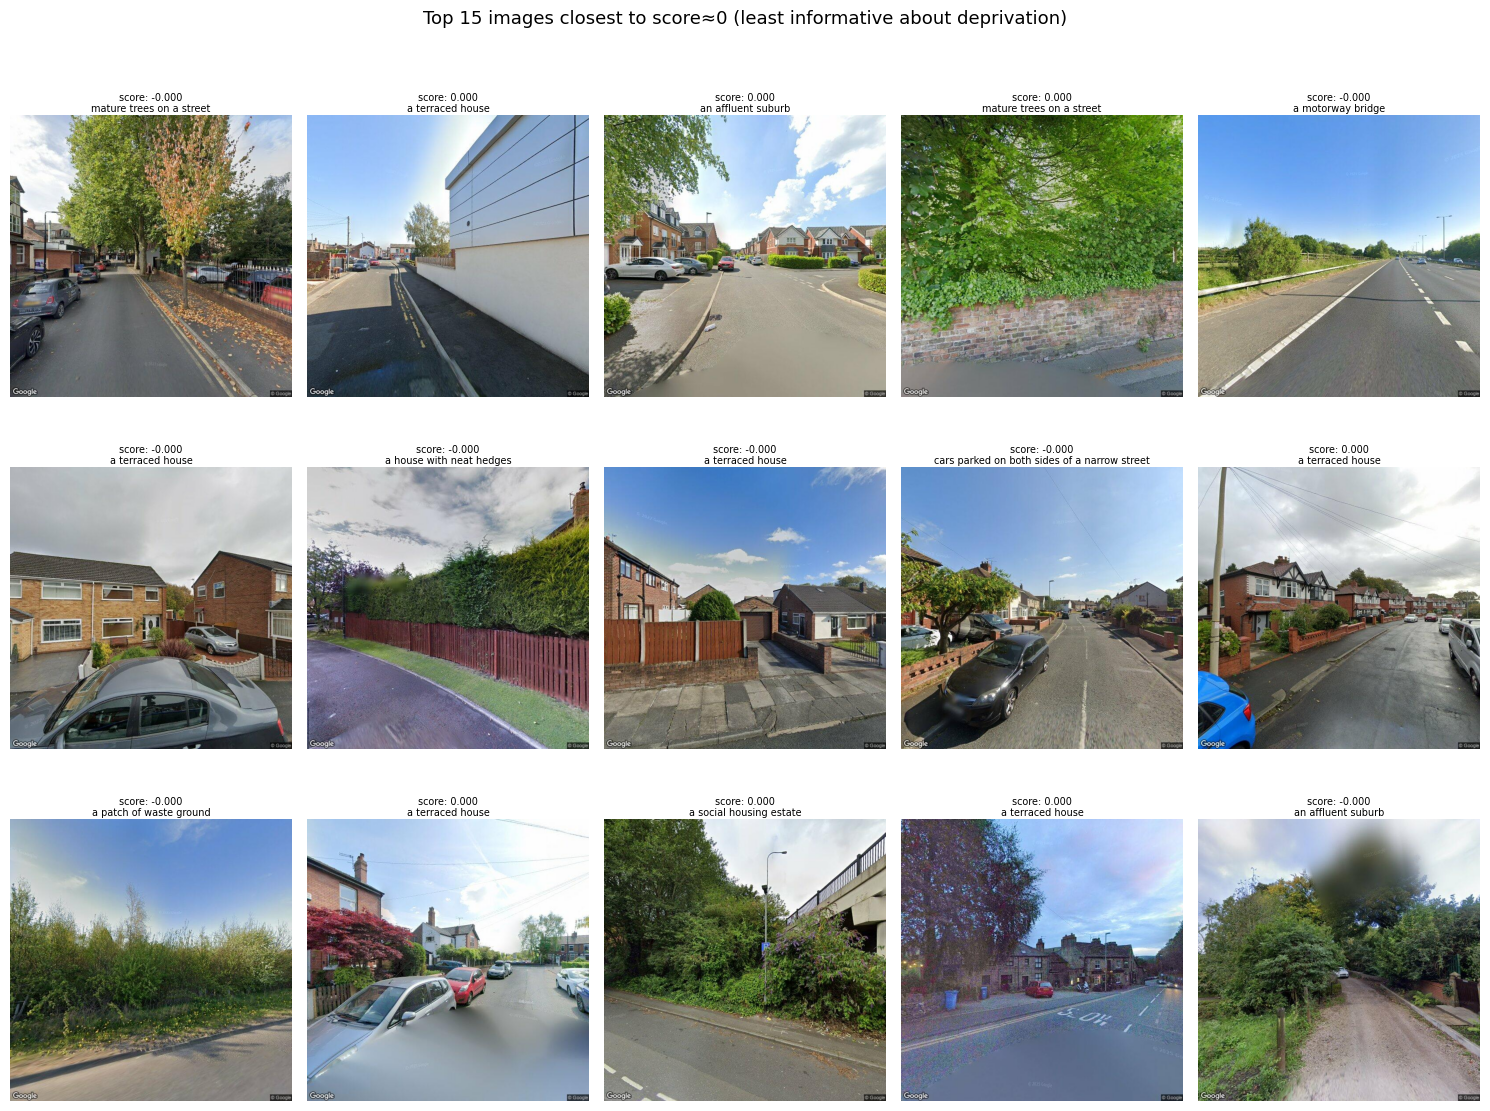

In [11]:
def show_jpegs(h5_rows, h5_slots, title, save_as, scores=None, best_prompts=None):
    """Load the JPEGs at the given (row, slot) pairs from the H5 store and tile them.
    
    Optionally annotates each image with its deprivation score and best-matching prompt.
    """
    n = len(h5_rows)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
    # Extra vertical space for text labels beneath each image
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3.8 * nrows))
    axes = np.atleast_2d(axes).ravel()
    with h5py.File(h5_filename, "r") as f:
        jpeg_ds = f["images_jpeg"]
        for k, (r, s) in enumerate(zip(h5_rows, h5_slots)):
            img = Image.open(io.BytesIO(jpeg_ds[r, s].tobytes())).convert("RGB")
            axes[k].imshow(img)
            axes[k].set_axis_off()
            # Build per-image subtitle: score on first line, best prompt on second
            parts = []
            if scores is not None:
                parts.append(f"score: {scores[k]:.3f}")
            if best_prompts is not None:
                parts.append(best_prompts[k])
            if parts:
                axes[k].set_title("\n".join(parts), fontsize=7, pad=3, wrap=True)
    for ax in axes[len(h5_rows):]:
        ax.set_axis_off()
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(outputs_dir, save_as), dpi=150, bbox_inches="tight")
    plt.show()

# Compute per-image best-matching prompt using raw (un-centered) cosine similarity.
# img_emb and T are both unit-norm, so their dot product is the cosine similarity.
img_prompt_sims = img_emb @ T.T          # (M, n_prompts)
best_prompt_idx = np.argmax(img_prompt_sims, axis=1)   # (M,) index into `prompts`

# Sort orders
order_affluent = np.argsort(-img_scores)   # high score first
order_deprived = np.argsort(img_scores)    # low score first
order_neutral  = np.argsort(np.abs(img_scores))  # closest to 0 first

def pick_unique_rows(order, k=15):
    """Pick k images, one per sample point, in the given sorted order.
    
    Returns parallel lists of (h5_row, slot, score, best_prompt).
    """
    chosen_rows, chosen_slots, chosen_scores, chosen_prompts = [], [], [], []
    seen = set()
    for idx in order:
        r = int(rows[idx])
        if r in seen:
            continue
        seen.add(r)
        chosen_rows.append(r)
        chosen_slots.append(int(slots[idx]))
        chosen_scores.append(float(img_scores[idx]))
        chosen_prompts.append(prompts[best_prompt_idx[idx]])
        if len(chosen_rows) >= k:
            break
    return chosen_rows, chosen_slots, chosen_scores, chosen_prompts

aff_r, aff_s, aff_scores, aff_prompts = pick_unique_rows(order_affluent, 15)
dep_r, dep_s, dep_scores, dep_prompts = pick_unique_rows(order_deprived, 15)
neu_r, neu_s, neu_scores, neu_prompts = pick_unique_rows(order_neutral,  15)

show_jpegs(aff_r, aff_s,
           "Top 15 images aligned with the AFFLUENT end of the deprivation direction",
           "10-extreme_images_affluent.png",
           scores=aff_scores, best_prompts=aff_prompts)

show_jpegs(dep_r, dep_s,
           "Top 15 images aligned with the DEPRIVATION end of the deprivation direction",
           "10-extreme_images_deprived.png",
           scores=dep_scores, best_prompts=dep_prompts)

show_jpegs(neu_r, neu_s,
           "Top 15 images closest to score≈0 (least informative about deprivation)",
           "10-extreme_images_neutral.png",
           scores=neu_scores, best_prompts=neu_prompts)

### Notes on the panels above

Each image is annotated with its **deprivation-direction score** (positive = more affluent-looking, negative = more deprivation-looking) and the **phrase from the prompt bank with the highest raw cosine similarity** to that image's CLIP embedding. The third panel shows the 15 images whose scores are closest to zero — these images sit near the midpoint of the deprivation axis and carry the least information about deprivation status.

## 7. Sensitivity: how stable is the direction?

A single direction learned from 1,695 LSOAs might be unstable. We bootstrap-resample the LSOAs, refit the ridge on each resample, and measure how aligned the resulting $\mathbf{w}^{(b)}$ vectors are with our original $\mathbf{w}$. If the bootstrap directions are all close to the original (cosine similarity $\approx 1$), the conclusions above are reliable. If they vary wildly, the ranking of prompts should be interpreted with caution.

Bootstrap cosine similarity with original direction:
  mean = 0.854,  min = 0.821,  max = 0.880


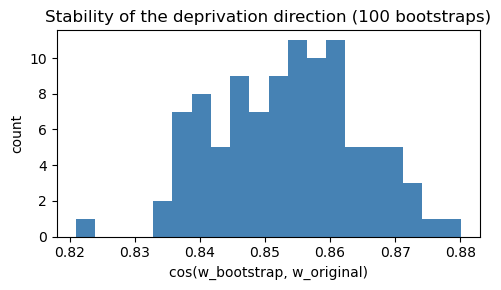

In [12]:
B = 100
rng = np.random.default_rng(RANDOM_STATE)
boot_cos = np.empty(B)
for b in range(B):
    idx = rng.integers(0, len(X), size=len(X))
    r_b = Ridge(alpha=ridge.alpha_).fit(X[idx], y_z[idx])
    w_b = r_b.coef_
    boot_cos[b] = (w_b @ w) / (np.linalg.norm(w_b) * np.linalg.norm(w))

print(f"Bootstrap cosine similarity with original direction:")
print(f"  mean = {boot_cos.mean():.3f},  min = {boot_cos.min():.3f},  max = {boot_cos.max():.3f}")
plt.figure(figsize=(5, 3))
plt.hist(boot_cos, bins=20, color="steelblue")
plt.xlabel("cos(w_bootstrap, w_original)")
plt.ylabel("count"); plt.title(f"Stability of the deprivation direction ({B} bootstraps)")
plt.tight_layout(); plt.show()

## 8. Sanity check: how much signal do interpretable concepts capture?

The direction analysis above tells us what the model "thinks" deprivation looks like in English. But maybe those English descriptions are a pale shadow of what the 512-dim embedding really encodes. The cleanest way to ask this is:

> **If we replace each LSOA's 512-dim embedding with the much smaller vector of its similarities to every prompt, how much of the predictive power do we keep?**

If the concept-score model is nearly as good as the raw-embedding model, most of the signal can be described in plain English (which is what we want for the paper). If it is dramatically worse, some of the signal remains in dimensions we cannot yet name.

In [13]:
# For each LSOA, compute its similarity to every prompt (n_lsoa, n_prompts).
concept_scores = X @ T.T
concept_df = pd.DataFrame(concept_scores, columns=prompts, index=df["LSOA21CD"].values)
concept_df.to_pickle(os.path.join(data_dir, "per_lsoa_embedding_summaries", "concept_scores_per_lsoa.pkl"))
print("Concept-score matrix:", concept_scores.shape)

# Two models for head-to-head comparison, both on standardised IMD rank:
#   A) Ridge on raw 512-dim embeddings (the direction model itself)
#   B) Ridge on the (n_lsoa, n_prompts) concept-score matrix
pipe_raw = Pipeline([("sc", StandardScaler()), ("reg", RidgeCV(alphas=np.logspace(-2, 3, 12)))])
pipe_con = Pipeline([("sc", StandardScaler()), ("reg", RidgeCV(alphas=np.logspace(-2, 3, 12)))])

r2_raw = cross_val_score(pipe_raw, X,              y_z, cv=cv, scoring="r2").mean()
r2_con = cross_val_score(pipe_con, concept_scores, y_z, cv=cv, scoring="r2").mean()
print(f"CV R^2 (raw 512-d CLIP embedding):        {r2_raw:.3f}")
print(f"CV R^2 (human-readable concept scores):   {r2_con:.3f}")
print(f"Script 4 XGBoost headline (for reference): 0.660")

Concept-score matrix: (1695, 115)
CV R^2 (raw 512-d CLIP embedding):        0.676
CV R^2 (human-readable concept scores):   0.621
Script 4 XGBoost headline (for reference): 0.660


## 9. Takeaway

What this notebook produces, to be written up in the paper:

- A **ranked list** of English phrases describing each end of the axis along which the model separates deprived from affluent LSOAs. This directly answers the question the Discussion flagged as future work, without needing to hand-assign images to a small list of classes.
- **Extreme-image galleries** that let a lay reader see, with their own eyes, what the model has learned to associate with each end of the deprivation scale.
- A **stability diagnostic** quantifying how reliable the direction is under LSOA resampling.
- A **concept-score regression** that bounds how much of the predictive signal is captured by interpretable concepts. Reporting the gap between $R^2_{\text{raw}}$ and $R^2_{\text{concepts}}$ is an honest way to say "here is how much of the story we can tell in plain English" — and, if the gap is large, a motivation for further work.

### Caveats

- CLIP was trained on generic web imagery, not on UK street-view. Some of its text–image alignments may be skewed toward North-American visual stereotypes. This is a ceiling on the interpretability exercise: a UK-tuned CLIP would likely yield crisper English descriptions.
- A linear direction can only capture the component of the XGBoost model that *is* linear. The ridge CV-R² above is a lower bound on how much of the signal we are interpreting.
- The prompt bank is a human artefact. We mitigate this by making it large and redundant and by showing that the extreme-image retrieval (which uses no prompts at all) tells a consistent story.